# CropHarvest: Benchmark Inspection

One sample is one labeled pixel time series. CropHarvest exposes Sentinel-2, Sentinel-1, climate/topography, labels, source dataset groups, coordinates, and representative years.


## Setup


In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from dataio.get_input import get_input
from dataio.inspection import benchmark_input_contract_table, benchmark_metadata_table

REPO = Path.cwd()
while not (REPO / "src").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src"))

BENCHMARK_ROOT = REPO / "data" / "input" / "benchmarks"
print("repo:", REPO)
print("benchmark root:", BENCHMARK_ROOT)

repo: /Users/akshithchowdary/Developer/Projects/org/abe/robustness
benchmark root: /Users/akshithchowdary/Developer/Projects/org/abe/robustness/data/input/benchmarks


## Load Benchmark


In [2]:

MAX_SAMPLES = 5000
LOAD_KWARGS = {}

bench = None
load_error = None
try:
    bench = get_input("cropharvest", root=BENCHMARK_ROOT, max_samples=MAX_SAMPLES, shuffle=False, **LOAD_KWARGS)
    print(f"loaded {bench.name}: {bench.n_samples} samples")
except Exception as exc:
    load_error = exc
    print(f"benchmark could not be loaded locally: {type(exc).__name__}: {exc}")

   !! CropHarvest: 64867 labeled arrays were unreadable/malformed in /Users/akshithchowdary/Developer/Projects/org/abe/robustness/data/input/benchmarks/cropharvest/features/arrays -- those samples are skipped (set STRICT_MODE=True to fail instead)
loaded cropharvest: 2826 samples


## Input Contract and Available Metadata


In [3]:
if bench is None:
    display(Markdown(f"Benchmark tables are skipped because the local data could not be read: `{type(load_error).__name__}: {load_error}`"))
else:
    display(Markdown("### Model-facing input contract"))
    display(benchmark_input_contract_table(bench))
    display(Markdown("### Other benchmark metadata available"))
    display(benchmark_metadata_table(bench))

### Model-facing input contract

,field,scope,dtype/type,coverage,example / summary,role
0,s2,sample time series,float32,1/1,"B2, B3, B4, B5, B6, B7, B8, B8A, B9, B11, B12,...",model input modality
1,s1,sample time series,float32,1/1,"VV, VH",model input modality
2,climate,sample time series,float32,1/1,"temperature, precipitation, elevation, slope",model input modality
3,latlon,sample,float32,2826/2826 (100.0%),"[lat, lon]",location input where used
4,time,sample/observation,int64,2826/2826 (100.0%),"months, day-of-year, years",temporal input metadata
5,labels,sample,int64,2826/2826 (100.0%),class id / target value,supervision


### Other benchmark metadata available

,field,scope,dtype/type,coverage,example / summary,role
0,labels,sample,int64,2826/2826 (100.0%),"1: 2141, 0: 685",supervision target before task-specific coarse...
1,groups,sample,object,2826/2826 (100.0%),"usa-kern: 932, geowiki-landcover-2017: 625, cr...",split / holdout group
2,years,sample,int64,2826/2826 (100.0%),"min=2016, max=2020, values=2016, 2017, 2018, 2...",representative calendar year
3,latlon,sample,float64,2826/2826 (100.0%),lat -43.05..58.95; lon -154.2..177.8,geographic coordinate
4,s2.bands,modality,list[str],1/1,"12 bands: B2, B3, B4, B5, B6, B7, B8, B8A, ...",native band names
5,s2.observation_count,sample,int64,2826/2826 (100.0%),"min=12, median=12, max=12",native acquisition count
6,s1.bands,modality,list[str],1/1,"2 bands: VV, VH",native band names
7,s1.observation_count,sample,int64,2826/2826 (100.0%),"min=12, median=12, max=12",native acquisition count
8,climate.bands,modality,list[str],1/1,"4 bands: temperature, precipitation, elevation...",native band names
9,climate.observation_count,sample,int64,2826/2826 (100.0%),"min=12, median=12, max=12",native acquisition count


## Dataset Summary


In [4]:
if bench is not None and hasattr(bench, "native"):
    rows = []
    for modality in ("s2", "s1", "climate"):
        series = getattr(bench.native, modality)
        lengths = np.array([len(v) for v in series.values], dtype=int)
        rows.append({
            "modality": modality,
            "bands": len(series.bands),
            "band_names": ", ".join(series.bands) if series.bands else "-",
            "min_observations": int(lengths.min()) if len(lengths) else 0,
            "median_observations": float(np.median(lengths)) if len(lengths) else 0,
            "max_observations": int(lengths.max()) if len(lengths) else 0,
        })
    display(pd.DataFrame(rows))
else:
    print("native modality summary skipped")

,modality,bands,band_names,min_observations,median_observations,max_observations
0,s2,12,"B2, B3, B4, B5, B6, B7, B8, B8A, B9, B11, B12,...",12,12.0,12
1,s1,2,"VV, VH",12,12.0,12
2,climate,4,"temperature, precipitation, elevation, slope",12,12.0,12


## Dataset Summary


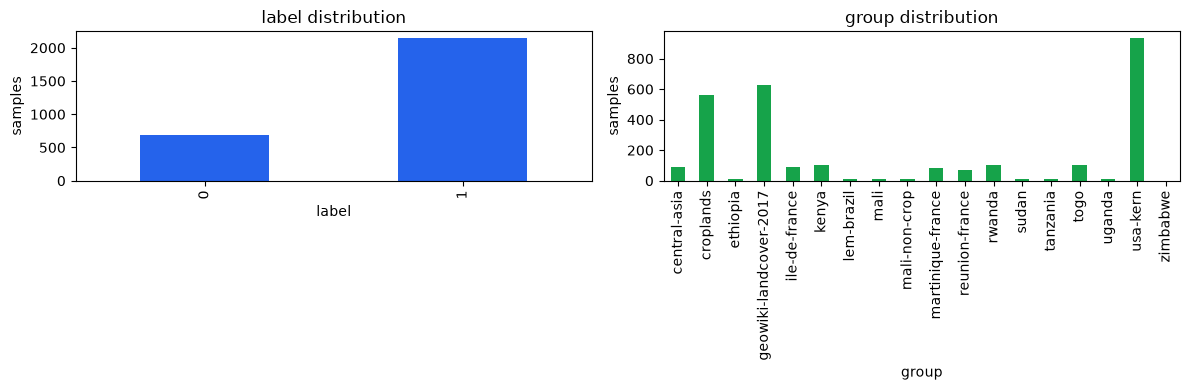

In [5]:
if bench is not None and hasattr(bench, "labels"):
    labels = np.asarray(bench.labels)
    groups = np.asarray(bench.groups, dtype=object)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    pd.Series(labels).value_counts().sort_index().plot(kind="bar", ax=ax[0], color="#2563eb")
    ax[0].set_title("label distribution")
    ax[0].set_xlabel("label")
    ax[0].set_ylabel("samples")
    pd.Series(groups).value_counts().sort_index().plot(kind="bar", ax=ax[1], color="#16a34a")
    ax[1].set_title("group distribution")
    ax[1].set_xlabel("group")
    ax[1].set_ylabel("samples")
    plt.tight_layout()
    plt.show()
else:
    print("sample-level label/group plot skipped")

## Takeaways

CropHarvest is the binary crop/non-crop benchmark. `groups` are source datasets for geographic holdout. Coordinates and years are available as benchmark metadata, and S1/climate/topography are available model-facing modalities.
